In [27]:
import pickle
import os
from pathlib import Path
from collections import defaultdict

import numpy as np
from loguru import logger
import matplotlib.pyplot as plt

from behave_analysis.process.session import get_experiment
from behave_analysis.analyze.overview.homing_analysis.decoding_spatial_eff.model import compute_accuracy_data, plot_accuracy_across_sessions

# Importing the mice sessions to use

In [2]:
from behave_analysis.database.Experiments.JAL003_ex import JAL3_25aug, JAL3_1sept, JAL3_4sept, JAL3_7sept
from behave_analysis.database.Experiments.JAL004_ex import JAL4_3rdSept, JAL4_19thSept, JAL4_28aug, JAL4_11thSept
from behave_analysis.database.Experiments.JAL005_ex import JAL005_8thSept, JAL005_21stSept
from behave_analysis.database.Experiments.JAL006_ex import JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar, JAL6_flip3_18mar, JAL6_flip7_1apr
from behave_analysis.database.Experiments.JAL007_ex import JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr,JAL7_30apr
from behave_analysis.database.Experiments.JAL008_ex import JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_tiny_3may, JAL8_flip4_10may, JAL8_14may, JAL8_21may, JAL8_flip3_7may

# Defined session names, experiments and hash mice to sessions

In [3]:
# The values must be in order of data for the code to work
mice_groups = {
    "JAL6": ['JAL6_flip3_18mar', 'JAL6_flip4_21mar', 'JAL6_flip5_25mar', 'JAL6_28mar'],
    "JAL3": ['JAL3_25aug', 'JAL3_1sept', 'JAL3_4sept', 'JAL3_7sept'],
    "JAL7": ['JAL7_flip2_12mar', 'JAL7_flip5_22mar', 'JAL7_sesh8_9apr', 'JAL7_sesh9_16apr', 'JAL7_23apr'],
    "JAL8": ['JAL8_flip1_25apr', 'JAL8_flip2_29apr', 'JAL8_flip4_10may', "JAL8_flip3_7may", 'JAL8_14may'],
    "JAL4": ['JAL4_28aug', 'JAL4_3rdSept', 'JAL4_11thSept', 'JAL4_19thSept'],
    "JAL5": ['JAL5_8thSept', 'JAL5_21stSept']}

# The experiment objects index must match the session name index for the code to work
experiments_objects = [JAL6_flip3_18mar, JAL6_flip4_21mar, JAL6_flip5_25mar, JAL6_28mar,
                       JAL3_25aug, JAL3_1sept, JAL3_4sept, JAL3_7sept,
                       JAL005_8thSept, JAL005_21stSept,
                       JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr,
                       JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_flip4_10may, JAL8_14may, JAL8_flip3_7may,
                       JAL4_3rdSept, JAL4_19thSept, JAL4_28aug, JAL4_11thSept]

# The session name indexes must match the experiment object indexes
session_names = ["JAL6_flip3_18mar", "JAL6_flip4_21mar", "JAL6_flip5_25mar", "JAL6_28mar",
                 "JAL3_25aug", "JAL3_1sept", "JAL3_4sept", "JAL3_7sept",
                 "JAL5_8thSept", "JAL5_21stSept",
                 "JAL7_sesh8_9apr", "JAL7_sesh9_16apr", "JAL7_flip5_22mar", "JAL7_flip2_12mar", "JAL7_23apr",
                 "JAL8_flip1_25apr", "JAL8_flip2_29apr", "JAL8_flip4_10may", "JAL8_14may", "JAL8_flip3_7may",
                 "JAL4_3rdSept", "JAL4_19thSept", "JAL4_28aug", "JAL4_11thSept"]

# Load the data

In [4]:
# This cell is only required if you wish to re-generate the accuracy data below. Else if you want to genreate data for the model you will need to go into the data generation script. As this cell loads pre-generated data. 

dir = Path("Z:\Jasmine_Laurence\single_trial_overview\decoding_spatial_efficiency")
name_of_data = "compute_the_first_20_frames_before_homing"
path = dir / f"{name_of_data}.pkl"
with open(path, "rb") as f:
    compute_the_first_20_frames_before_homing =  pickle.load(f)

# Generate the accuracy data

In [7]:
# If the accuracy data does not exist, create it. Or if you want to run a control test or another window of data.
# Else, you will load the accuracy data below.

test = compute_accuracy_data(
        data_type=compute_the_first_20_frames_before_homing, 
        experiments_objects= experiments_objects, 
        data_type_name="500ms_before_accuracy", 
        random_labels=False
    )

2025-01-15 18:54:10.832 | INFO     | behave_analysis.analyze.overview.homing_analysis.decoding_spatial_eff.model:compute_accuracy_data:300 - Running logistic regression for session: JAL6_flip3_18mar
2025-01-15 18:54:32.285 | INFO     | behave_analysis.analyze.overview.homing_analysis.decoding_spatial_eff.model:compute_accuracy_data:323 - Class distribution for fold: 0. 0: 220, 1: 240


Class distribution before down sampling. 0: 460, 1: 1640
Class distribution for the entire session after down sampling. 0: 460, 1: 460


2025-01-15 18:54:33.895 | INFO     | behave_analysis.analyze.overview.homing_analysis.decoding_spatial_eff.model:compute_accuracy_data:323 - Class distribution for fold: 1. 0: 240, 1: 220
2025-01-15 18:54:35.367 | INFO     | behave_analysis.analyze.overview.homing_analysis.decoding_spatial_eff.model:compute_accuracy_data:340 - Mean accuracy for session JAL6_flip3_18mar: 0.6054347826086957
2025-01-15 18:54:35.368 | INFO     | behave_analysis.analyze.overview.homing_analysis.decoding_spatial_eff.model:compute_accuracy_data:300 - Running logistic regression for session: JAL6_flip4_21mar
2025-01-15 18:54:56.782 | INFO     | behave_analysis.analyze.overview.homing_analysis.decoding_spatial_eff.model:compute_accuracy_data:323 - Class distribution for fold: 0. 0: 240, 1: 259


Class distribution before down sampling. 0: 500, 1: 1780
Class distribution for the entire session after down sampling. 0: 500, 1: 500


2025-01-15 18:54:58.398 | INFO     | behave_analysis.analyze.overview.homing_analysis.decoding_spatial_eff.model:compute_accuracy_data:323 - Class distribution for fold: 1. 0: 260, 1: 241
2025-01-15 18:54:59.925 | INFO     | behave_analysis.analyze.overview.homing_analysis.decoding_spatial_eff.model:compute_accuracy_data:340 - Mean accuracy for session JAL6_flip4_21mar: 0.5540262161048644
2025-01-15 18:54:59.926 | INFO     | behave_analysis.analyze.overview.homing_analysis.decoding_spatial_eff.model:compute_accuracy_data:300 - Running logistic regression for session: JAL6_flip5_25mar
2025-01-15 18:55:21.439 | INFO     | behave_analysis.analyze.overview.homing_analysis.decoding_spatial_eff.model:compute_accuracy_data:323 - Class distribution for fold: 0. 0: 40, 1: 60


...

2025-01-15 19:03:36.973 | INFO     | behave_analysis.analyze.overview.homing_analysis.decoding_spatial_eff.model:compute_accuracy_data:323 - Class distribution for fold: 1. 0: 80, 1: 60
2025-01-15 19:03:38.494 | INFO     | behave_analysis.analyze.overview.homing_analysis.decoding_spatial_eff.model:compute_accuracy_data:340 - Mean accuracy for session JAL4_19thSept: 0.7642857142857142
2025-01-15 19:03:38.495 | INFO     | behave_analysis.analyze.overview.homing_analysis.decoding_spatial_eff.model:compute_accuracy_data:300 - Running logistic regression for session: JAL4_28aug
2025-01-15 19:03:57.681 | INFO     | behave_analysis.analyze.overview.homing_analysis.decoding_spatial_eff.model:compute_accuracy_data:323 - Class distribution for fold: 0. 0: 80, 1: 74


Class distribution before down sampling. 0: 160, 1: 220
Class distribution for the entire session after down sampling. 0: 160, 1: 160


2025-01-15 19:03:59.121 | INFO     | behave_analysis.analyze.overview.homing_analysis.decoding_spatial_eff.model:compute_accuracy_data:323 - Class distribution for fold: 1. 0: 80, 1: 86
2025-01-15 19:04:00.521 | INFO     | behave_analysis.analyze.overview.homing_analysis.decoding_spatial_eff.model:compute_accuracy_data:340 - Mean accuracy for session JAL4_28aug: 0.5692771084337349
2025-01-15 19:04:00.522 | INFO     | behave_analysis.analyze.overview.homing_analysis.decoding_spatial_eff.model:compute_accuracy_data:300 - Running logistic regression for session: JAL4_11thSept
2025-01-15 19:04:27.082 | INFO     | behave_analysis.analyze.overview.homing_analysis.decoding_spatial_eff.model:compute_accuracy_data:323 - Class distribution for fold: 0. 0: 80, 1: 83


Class distribution before down sampling. 0: 160, 1: 260
Class distribution for the entire session after down sampling. 0: 160, 1: 160


2025-01-15 19:04:28.548 | INFO     | behave_analysis.analyze.overview.homing_analysis.decoding_spatial_eff.model:compute_accuracy_data:323 - Class distribution for fold: 1. 0: 80, 1: 77
2025-01-15 19:04:30.089 | INFO     | behave_analysis.analyze.overview.homing_analysis.decoding_spatial_eff.model:compute_accuracy_data:340 - Mean accuracy for session JAL4_11thSept: 0.6413778281427064


In [11]:
model_accuracy = test[0]
model_coeffs = test[2]

# Load prior accuracy and coefficients

In [21]:
with open(r"Z:\Jasmine_Laurence\single_trial_overview\decoding_spatial_efficiency\500ms_before_accuracy\500ms_before_accuracy_accuracy_ks_coeffs_data.pkl", "rb") as f:
    accuracy_ks_coeffs_data = pickle.load(f)

In [22]:
# Rename
model_coeffs = accuracy_ks_coeffs_data["coefs"]
model_accuracy = accuracy_ks_coeffs_data["accuracy_data"]

# Average the coefficients across folds

In [23]:
average_coefs = {}
for session_name, folds in model_coeffs.items():
    # Stack the coefficients from all folds and compute the mean
    coefficients = np.array(list(folds.values()))  # Shape: (num_folds, num_features)
    average_coefs[session_name] = coefficients.mean(axis=0)  # Average across folds

# Load head direction cells

In [24]:
with open(r"Z:\Jasmine_Laurence\single_trial_overview\decoding_spatial_efficiency\head_direction_cells.pkl", "rb") as f:
    head_direction = pickle.load(f)

Retrieve the head direction ids and top coefficients for each session, and store how many head direction cells there are. And how many of those cell IDs intersect with the top coefficients for the logistic regression.

In [35]:
coeff_counts = defaultdict(defaultdict)
excluded_sessions = ["JAL6_flip5_25mar", "JAL8_flip4_10may", "JAL4_19thSept"] # Exlcude sessions because of missmatch of cells

for experiment, session_name in zip(experiments_objects, session_names):
    if session_name not in model_accuracy.keys(): # Some sessions might not have accuracy data because of the exclusion of the session if they don't meet a certain criteria
        logger.warning(f"Skipping session because of missed criteria: {session_name}")
        continue
    if session_name in excluded_sessions: # Exlcude sessions that have a bug for a miss match of cells between cluster matrix and good cluster ids array
        logger.error(f"Excluding session because of a bug: {session_name}")
        continue
    
    logger.info(f"Loading data for session: {session_name}")
    loaded_session = get_experiment(experiment)
    good_cluster_path = os.path.join(loaded_session.base_path, loaded_session.processed_path, "good_cluster_ids.npy")
    hdir_cells = np.array(head_direction[session_name])
    accuracy = model_accuracy[session_name]
    coefs_ = average_coefs[session_name]
    good_cluster_ids = np.load(good_cluster_path)
    assert len(good_cluster_ids) == len(coefs_), "The number of good cluster ids and coefficients do not match"
    top_20_indices = np.argsort(np.abs(coefs_))[-20:] # Get the indices of the top 20 coefficients 
    top_20_coefficients = coefs_[top_20_indices]
    assert max(coefs_) in top_20_coefficients, "The max coefficient is not in the top 20 coefficients"
    good_cluster_ids_top_20 = good_cluster_ids[top_20_indices] # Get the good cluster ids of the top 20 coefficients
    count_good_cluster_ids_top_20 = len(good_cluster_ids_top_20)
    hdir_cells_top_20 = np.intersect1d(hdir_cells, good_cluster_ids_top_20) # Get the head direction cells that are in the top 20 coefficients
    coeff_counts[session_name]["#_head_direction_cells"] = len(hdir_cells)
    coeff_counts[session_name]["#_hdir_cells_that_top_20"] = len(hdir_cells_top_20)

2025-01-15 19:22:40.291 | INFO     | __main__:<module>:12 - Loading data for session: JAL6_flip3_18mar
2025-01-15 19:22:40.344 | INFO     | __main__:<module>:12 - Loading data for session: JAL6_flip4_21mar
2025-01-15 19:22:40.355 | ERROR    | __main__:<module>:9 - Excluding session because of a bug: JAL6_flip5_25mar
2025-01-15 19:22:40.356 | INFO     | __main__:<module>:12 - Loading data for session: JAL6_28mar
2025-01-15 19:22:40.366 | INFO     | __main__:<module>:12 - Loading data for session: JAL3_25aug
2025-01-15 19:22:40.377 | INFO     | __main__:<module>:12 - Loading data for session: JAL3_1sept
2025-01-15 19:22:40.386 | INFO     | __main__:<module>:12 - Loading data for session: JAL3_4sept
2025-01-15 19:22:40.394 | INFO     | __main__:<module>:12 - Loading data for session: JAL3_7sept
2025-01-15 19:22:40.404 | INFO     | __main__:<module>:12 - Loading data for session: JAL5_8thSept
2025-01-15 19:22:40.412 | WARNING  | __main__:<module>:6 - Skipping session because of missed crit

# Plot

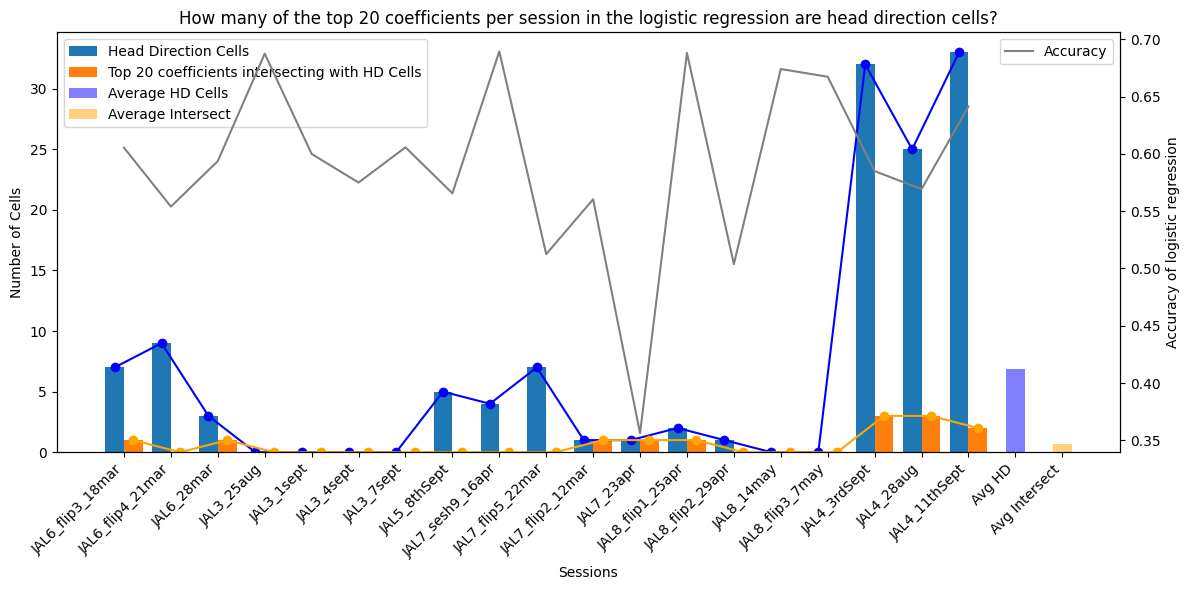

In [32]:
data = coeff_counts

# Prepare data for plotting
sessions = list(data.keys())
hd_cells = [data[session]['#_head_direction_cells'] for session in sessions]
top_20_hd_cells = [data[session]['#_hdir_cells_that_top_20'] for session in sessions]
accuracies = [model_accuracy[session] for session in sessions]

# Calculate averages
average_hd_cells = np.mean(hd_cells)
average_top_20_hd_cells = np.mean(top_20_hd_cells)

# Bar positions
x_positions = np.arange(len(sessions))

# Plotting
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot bars on the primary y-axis
bar_width = 0.4
bar1 = ax1.bar(x_positions - bar_width / 2, hd_cells, bar_width, label='Head Direction Cells')
bar2 = ax1.bar(x_positions + bar_width / 2, top_20_hd_cells, bar_width, label='Top 20 coefficients intersecting with HD Cells')

# Plot points and lines on the primary y-axis
ax1.plot(x_positions - bar_width / 2, hd_cells, 'o-', color='blue')
ax1.plot(x_positions + bar_width / 2, top_20_hd_cells, 'o-', color='orange')

# Average bars on the primary y-axis
ax1.bar(len(sessions), average_hd_cells, bar_width, label='Average HD Cells', color='blue', alpha=0.5)
ax1.bar(len(sessions) + 1, average_top_20_hd_cells, bar_width, label='Average Intersect', color='orange', alpha=0.5)

# Secondary y-axis for accuracy
ax2 = ax1.twinx()
ax2.plot(x_positions, accuracies, color='gray', label='Accuracy')

# Customizing the primary y-axis
ax1.set_xlabel('Sessions')
ax1.set_ylabel('Number of Cells')
ax1.set_title('How many of the top 20 coefficients per session in the logistic regression are head direction cells?')
ax1.set_xticks(list(x_positions) + [len(sessions), len(sessions) + 1])
ax1.set_xticklabels(sessions + ['Avg HD', 'Avg Intersect'], rotation=45, ha='right')
ax1.legend(loc='upper left')

# Customizing the secondary y-axis
ax2.set_ylabel('Accuracy of logistic regression')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

# Plot the average accuracy across sessions 

In [ ]:
plot_accuracy_across_sessions(model_accuracy, mice_groups=mice_groups, plot_title="500ms before homing")

# Pull out the specific cell IDs of top cells so we can see what their receptive fields look like by going through the single cluster plots

In [ ]:
_14th_may_coefs = average_coefs["JAL8_14may"]
_7th_may_coefs = average_coefs["JAL8_flip3_7may"]

# Load the followng numpy arrau
_14_file = np.load(r"W:\branco\Laurence\JAL008\JAL008_shelter_barrier_flip_5_2024_05_14T10_18_03\processed_data\good_cluster_Ids.npy")
_7_file = np.load(r"W:\branco\Laurence\JAL008\JAL008_shelter_barrier_flip_3_2024_05_07T10_16_26\processed_data\good_cluster_Ids.npy")

# Acess the top positive 10 coefficients for the 14th may
_14th_may_indices = np.argsort(_14th_may_coefs)[::-1][:10]

print("The top 10 positive coefficients for the 14th may are", _14th_may_indices)
print("The top 10 positive coefficients for the 14th may are", _14th_may_coefs[_14th_may_indices])
print("The cell IDs for the 14th may are", sorted(_14_file[_14th_may_indices]))

# Acess the top positive 10 coefficients for the 7th may
_7th_may_indices = np.argsort(_7th_may_coefs)[::-1][:10]

print("The top 10 positive coefficients for the 7th may are", _7th_may_indices)
print("The top 10 positive coefficients for the 7th may are", _7th_may_coefs[_7th_may_indices])
print("The cell IDs for the 7th may are", sorted(_7_file[_7th_may_indices]))


# Plot the KS vs decoding accuracy analysis

In [ ]:
# Extract average, max KS stats, and accuracies
def extract_ks_and_accuracy(data):
    avg_ks_values = []
    max_ks_values = []
    accuracies = []

    for session, trials in data.items():
        for trial, metrics in trials.items():
            if all(k in metrics for k in ['x', 'y', 'speed', 'hdir', 'accuracy']):
                ks_values = [metrics['x'], metrics['y'], metrics['speed'], metrics['hdir']]
                avg_ks_values.append(np.mean(ks_values))
                max_ks_values.append(np.max(ks_values))
                accuracies.append(metrics['accuracy'])

    return np.array(avg_ks_values), np.array(max_ks_values), np.array(accuracies)

# Perform the correlation analysis
def analyze_correlation(ks_values, accuracies):
    correlation = np.corrcoef(ks_values, accuracies)[0, 1]
    return correlation

# Extract data
avg_ks_values, max_ks_values, accuracies = extract_ks_and_accuracy(_500ms_before_ks_decoding_comparison)

# Check for sufficient data
if len(avg_ks_values) > 0 and len(max_ks_values) > 0 and len(accuracies) > 0:
    # Correlations
    avg_correlation = analyze_correlation(avg_ks_values, accuracies)
    max_correlation = analyze_correlation(max_ks_values, accuracies)

    print(f"Correlation between average KS statistic and decoding accuracy: {avg_correlation}")
    print(f"Correlation between max KS statistic and decoding accuracy: {max_correlation}")

    # Plot correlations across all sessions and folds
    plt.figure()
    plt.scatter(avg_ks_values, accuracies, alpha=0.7, label='Average KS')
    plt.scatter(max_ks_values, accuracies, alpha=0.7, label='Max KS', color='r')
    plt.xlabel('KS Statistic')
    plt.title(f"Max and Average KS Statistic vs Decoding Accuracy (Average r={avg_correlation:.2f}, Max r={max_correlation:.2f})")
    plt.legend()
    plt.show()

    # Plot individual KS variables against decoding accuracy
    ks_variables = ['x', 'y', 'speed', 'hdir']
    fig, axs = plt.subplots(2, 2, figsize=(10, 10))
    axs = axs.ravel()

    for i, var in enumerate(ks_variables):
        ks_values = []
        accuracies = []
        for session, trials in _500ms_before_ks_decoding_comparison.items():
            for trial, metrics in trials.items():
                if var in metrics and 'accuracy' in metrics:
                    ks_values.append(metrics[var])
                    accuracies.append(metrics['accuracy'])

        correlation = analyze_correlation(ks_values, accuracies)
        axs[i].scatter(ks_values, accuracies, alpha=0.7)
        axs[i].set_title(f'{var} vs Accuracy (r={correlation:.2f})')
        axs[i].set_xlabel("KS Statistic")
        axs[i].set_ylabel('Accuracy')

    plt.tight_layout()
    plt.show()
else:
    print("Insufficient data for analysis.")